In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.research.qcut_analyzer import QcutAnalyzer
# QcutAnalyzer.plot_qcut_analysis(df, col_a='Factor_A', col_b='Return')
%load_ext autoreload
%autoreload 2
from sdk_core import configure
from sdk_core import TwMarketData
# configure()
from src.research.rolling_model import train_and_predict_ridge_rolling

tw = TwMarketData()
# 取得還原股價
df = tw.get_security_price_adjusted("2025-12-31", "2330")

import os
import numpy as np
from tqdm import tqdm
import time
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
# 將最大顯示欄位數量設為 None（代表無上限）
pd.set_option('display.max_columns', None)

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pyarrow as pa
schema = pa.schema([
    ('price', pa.decimal128(10, 4)), 
    # 其他欄位如果沒特別指定，pyarrow 會自動推斷
])

from src.research.backTest import BackTest


In [2]:

folder_path = './data'  # 資料夾路徑
files = os.listdir(folder_path)

# 過濾掉資料夾，只留下檔案
file_names = np.array([f for f in files if os.path.isfile(os.path.join(folder_path, f))])
file_names.sort()
print(file_names[-5:])

['20260416.parquet' '20260417.parquet' '20260420.parquet'
 '20260421.parquet' '20260422.parquet']


In [3]:
data = []

# 範例：處理 100 個檔案
for f in tqdm (file_names[350:]): 
    targetLabel = 'BidPrice1' 
    rankThres_btn = 0
    rankThres = 150
    stock_df = pd.read_parquet( f'{folder_path}/{f}' )[lambda x : x[targetLabel] * x.BidPrice1 > 0]
    try : 
        stock_df['ToRef'] = ((stock_df['BidPrice1'] - stock_df.RefPrice) / stock_df.RefPrice ).round(6)
        stock_df['ToOpen'] = ((stock_df['BidPrice1'] - stock_df.Open) / stock_df.Open ).round(6)
        # stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        # stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.09 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.FutureHigh) / stock_df[targetLabel] * 10000)
        stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.08 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.RefPrice*1.08 - stock_df.TickSize*2) / stock_df[targetLabel] * 10000)
        PriceCondition = (stock_df.ToRef > -0.015) & (stock_df.ToRef < 0.05)
        # seqCondition = (stock_df.BidPrice1.diff()!= 0)
        AmountCondition = (stock_df.day_amount_rank <= rankThres) | (stock_df.AmountRank_canDayTrade <= rankThres) 
        # AmountCondition2 = (stock_df.day_amount_rank > rankThres_btn) & (stock_df.AmountRank > rankThres_btn)
        # preMarketCondition = (stock_df.day_amount_rank <= 50.1) | (stock_df.AmountRank <= 50.1)
        temp = stock_df[ PriceCondition & AmountCondition].reset_index(drop=True)
        temp['Date'] = f.split('.')[0]
        data.append(temp)
    except : 
        print('Filled in ', f)
        continue
        # break       
    # if f.split('.')[0] == '20260309':
    #     break

100%|██████████| 442/442 [00:58<00:00,  7.52it/s]


In [4]:
import gc

if 'signal_df' in locals():
    del signal_df
    gc.collect()

signal_df = pd.concat(data, ignore_index=True, copy=False)

priceReturnColumn = ["TransTime", "QuoteCode", "ChannelSeq","TotalFillLots","BidPrice1","BidLots1", "AskPrice1","AskLots1", "RecordHigh","FutureHigh", "RefPrice" , "Close" , "Open", "Spread", "TakerSell_CloseBP" ]
signal_df[priceReturnColumn + ['ToRef','FillLots_atLow','day_amount_rank', 'AmountRank', 'TimeSlot','TransTime_tb']].head(10)


/tmp/ipykernel_4013084/2134462285.py:7: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  signal_df = pd.concat(data, ignore_index=True, copy=False)


,TransTime,QuoteCode,ChannelSeq,TotalFillLots,BidPrice1,BidLots1,AskPrice1,AskLots1,RecordHigh,FutureHigh,RefPrice,Close,Open,Spread,TakerSell_CloseBP,ToRef,FillLots_atLow,day_amount_rank,AmountRank,TimeSlot,TransTime_tb
0,2024-06-24 09:03:17.045762,1101,418341,1842,34.60,126,34.70,114,34.75,34.65,34.65,34.25,34.7,2.0,101.156069,-0.001443,-398,128.0,NaN,None,NaT
1,2024-06-24 09:03:17.155915,1101,418495,1968,34.55,49,34.65,122,34.75,34.65,34.65,34.25,34.7,2.0,86.830680,-0.002886,-126,128.0,NaN,None,NaT
2,2024-06-24 09:03:17.195730,1101,418555,1968,34.60,2,34.65,122,34.75,34.65,34.65,34.25,34.7,1.0,101.156069,-0.001443,-126,128.0,NaN,None,NaT
3,2024-06-24 09:03:17.219520,1101,418602,1998,34.55,21,34.65,41,34.75,34.65,34.65,34.25,34.7,2.0,86.830680,-0.002886,-30,128.0,NaN,None,NaT
4,2024-06-24 09:03:24.628861,1101,430130,2038,34.55,49,34.65,65,34.75,34.60,34.65,34.25,34.7,2.0,86.830680,-0.002886,-4,128.0,NaN,None,NaT
5,2024-06-24 09:03:27.141276,1101,433810,2085,34.50,272,34.65,74,34.75,34.60,34.65,34.25,34.7,3.0,72.463768,-0.004329,-51,128.0,NaN,None,NaT
6,2024-06-24 09:03:27.939150,1101,434960,2085,34.55,1,34.65,74,34.75,34.60,34.65,34.25,34.7,2.0,86.830680,-0.002886,-51,128.0,NaN,None,NaT
7,2024-06-24 09:03:27.970824,1101,435012,2086,34.50,268,34.60,4,34.75,34.60,34.65,34.25,34.7,2.0,72.463768,-0.004329,-52,128.0,NaN,None,NaT
8,2024-06-24 09:03:30.957190,1101,439293,2089,34.55,1,34.60,22,34.75,34.60,34.65,34.25,34.7,1.0,86.830680,-0.002886,-49,128.0,NaN,None,NaT
9,2024-06-24 09:03:33.546950,1101,443411,2100,34.50,259,34.60,19,34.75,34.60,34.65,34.25,34.7,2.0,72.463768,-0.004329,-60,128.0,NaN,None,NaT


In [5]:
signal_df = signal_df[ (signal_df.TransTime.dt.time < datetime.time(12, 0, 0)) & (signal_df.TransTime.dt.time > datetime.time(9, 0, 30)) & (signal_df.TrialMatch == 0)].reset_index(drop=True)
signal_df = signal_df[  (signal_df.TakerSell_CloseBP.abs() < 10000) ].sort_values(['Date', 'QuoteCode', 'TransTime']).reset_index(drop=True)
signal_df['midEdge_300sBP'] = signal_df['midEdge_300sBP']*-1

<Axes: xlabel='Date'>

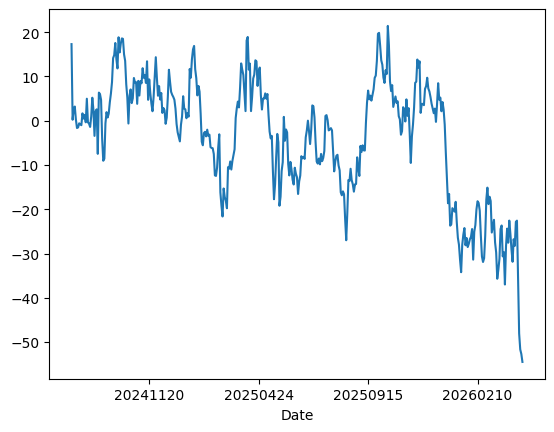

In [6]:
signal_df[:].groupby(['Date','QuoteCode']).TakerSell_CloseBP.mean().reset_index().groupby(['Date']).TakerSell_CloseBP.mean().rolling(30).mean().plot()

In [7]:
signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date','QuoteCode']).TakerSell_CloseBP.transform('mean')#.clip(lower=-130, upper=130)
signal_df['TakerSell_CloseBP_netM'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date']).TakerSell_CloseBP.transform('mean')#.clip(lower=-130, upper=130)
# signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date','QuoteCode']).TakerSell_CloseBP.transform('mean')#.clip(lower=-130, upper=130)
# signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date']).TakerSell_CloseBP.transform('mean')

In [8]:
import pandas as pd
import json

# 1. 讀取 JSON 檔案還原成 list
with open('abnormal_dates.json', 'r') as f:
    loaded_date_list = json.load(f)

signal_df['isAbnormalDate'] = signal_df['Date'].isin(loaded_date_list) *1

signal_df

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,FillLots_origin,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadCountAtSameCount,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,SpreadPairTotalCount,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,MarketCap,ClosePrice,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,hft_strick_participation,hft_strick_buy_ToCloseBP,hft_strick_buy_300sBP,hft_strick_sell_ToCloseBP,hft_strick_sell_300sBP,hft_strick_makerSpreadBP,firstMaker_buy_ToCloseBP,firstMaker_buy_300sBP,firstMaker_sell_ToCloseBP,firstMaker_sell_300sBP,firstMaker_makerSpreadBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,turnover_rate,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,AmountRank_canDayTrade,Date,TakerSell_CloseBP_net,TakerSell_CloseBP_netM,isAbnormalDate
0,2024-06-24 09:03:17.045762,2024-06-24 09:03:17.045762,1101,1101,1245067,418341,0,0,-1,0,1842,34.60,34.55,34.50,34.45,34.40,126,50,270,170,65,34.70,34.75,34.80,34.85,34.90,114,158,252,203,348,34.65,51,0.0,0,0.0,0,NaN,51,34.65,False,True,34.7,34.25,34.75,34.65,34.65,34.2,0.000000,0.002886,0.000000,-0.05,0.0,0.05,14.450867,34.650,-0.001443,-0.002882,-398,-393,236,0.525000,0.185022,0.258443,0.106047,0.253023,2.0,5,34.70,34.60,1,NaN,0.000000,0.044282,-1.0,51,608,6,15702,34.65,34.55,34.55,34.5,34.50,34.4,34.5,34.45,34.50,34.45,34.40,34.35,101.156069,-129.682997,-14.430014,-36.075036,-57.720058,-50.505051,50.505051,-79.365079,X,34897381.0,2.616484e+11,34.65,505415.0,-77377.0,0.0,12292496.0,510814.0,-767.0,-10.0,X,34327.0,14579.0,8382.0,273.896754,465.240637,8929.0,0.003621,15.0,56.502811,20.009582,10.0,-46.873451,-2.176637,0.048341,65.518698,21.823664,-43.478261,-14.482259,0.034674,64.072510,11.594061,-43.478261,-14.482259,72.716696,49.237622,10.040655,-51.975093,-15.548506,21.772939,-0.999998,-161.290323,-14.652015,34.720665,10.215633,NaN,77.681714,128.0,37.0,0.004546,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20240624,44.491968,-27.527878,0
1,2024-06-24 09:03:17.155915,2024-06-24 09:03:17.155915,1101,1101,1245221,418495,0,0,-1,0,1968,34.55,34.50,34.45,34.40,34.35,49,268,77,69,49,34.65,34.70,34.75,34.80,34.85,122,182,158,252,205,34.60,84,0.0,0,0.0,0,NaN,84,34.65,False,True,34.7,34.25,34.75,34.60,34.65,34.2,0.000000,0.004329,0.000000,-0.05,0.0,0.05,14.471780,34.600,-0.002886,-0.004323,-126,-519,110,0.286550,0.095703,

In [9]:
signal_df['B1_Last'] = signal_df.BidLots1 / signal_df.avg_bidLots1
signal_df['Total_Last'] = signal_df.TotalFillLots / signal_df.last_fillLots

In [10]:
based_columns = ['QuoteCode', 'ChannelSeq', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1','BidLots1', 'BidLots5', 'AskPrice1', 'AskLots1', 'AskLots5', 'FillLots']
feature_columns = ['ToLow', 'ToHigh', 'Low_High', 'TickSize', 'TickBP', 'ToRef', 'ToOpen', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'RemainSeconds']#'B1_Last','Total_Last']
cross_columns = ['AmountRank', 'netAmountRank', 'TotalFillLotsRank', 'netTotalFillLotsRank', 'ToRefRank']
day_columns = ['dealer_hedging_netLots', 'dealer_netLots', 'foreign_dealer_netLots', 'foreign_netLots', 'investment_netLots', 'margin_netLots', 'short_netLots', 'nextday_allow_day_trade_mark', 'trading_volume_noOdd', 'big_buy_lots', 'big_buy_ToCloseBP', 'big_buy_300sBP', 'big_sell_lots', 'big_sell_ToCloseBP', 'big_sell_300sBP', 'hft_participation', 'hft_buy_ToCloseBP', 'hft_buy_300sBP', 'hft_sell_ToCloseBP', 'hft_sell_300sBP', 'day_amount_rank', 'day_lots_rank']
# # 
feature = based_columns + feature_columns + cross_columns + day_columns
label = 'TakerSell_CloseBP_net'

feature_columns = ['ToLow', 'ToHigh', 'Low_High', 'ToRef', 'ToOpen', 'B1_A1B1', 'RemainSeconds', 'SpreadPairElapsed'] #
day_columns = ['foreign_netLots', 'investment_netLots','margin_netLots','turnover_rate','hft_strick_makerSpreadBP','hft_strick_participation','hft_participation','big_sell_ToCloseBP']

In [11]:
for c in feature_columns : 
    signal_df[c] = signal_df[c].round(6)
signal_df ['OTC'] = signal_df ['OTC'] * 1
signal_df ['isInvestBuy'] = ( ( signal_df ['investment_netLots']  > 1000) & (signal_df.OTC == True) ) * 1 

In [12]:
signal_df.head(1)

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,FillLots_origin,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadCountAtSameCount,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,SpreadPairTotalCount,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,MarketCap,ClosePrice,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,hft_strick_participation,hft_strick_buy_ToCloseBP,hft_strick_buy_300sBP,hft_strick_sell_ToCloseBP,hft_strick_sell_300sBP,hft_strick_makerSpreadBP,firstMaker_buy_ToCloseBP,firstMaker_buy_300sBP,firstMaker_sell_ToCloseBP,firstMaker_sell_300sBP,firstMaker_makerSpreadBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,turnover_rate,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,AmountRank_canDayTrade,Date,TakerSell_CloseBP_net,TakerSell_CloseBP_netM,isAbnormalDate,B1_Last,Total_Last,isInvestBuy
0,2024-06-24 09:03:17.045762,2024-06-24 09:03:17.045762,1101,1101,1245067,418341,0,0,-1,0,1842,34.6,34.55,34.5,34.45,34.4,126,50,270,170,65,34.7,34.75,34.8,34.85,34.9,114,158,252,203,348,34.65,51,0.0,0,0.0,0,NaN,51,34.65,0,True,34.7,34.25,34.75,34.65,34.65,34.2,0.0,0.002886,0.0,-0.05,0.0,0.05,14.450867,34.65,-0.001443,-0.002882,-398,-393,236,0.525,0.185022,0.258443,0.106047,0.253023,2.0,5,34.7,34.6,1,NaN,0.0,0.044282,-1.0,51,608,6,15702,34.65,34.55,34.55,34.5,34.5,34.4,34.5,34.45,34.5,34.45,34.4,34.35,101.156069,-129.682997,-14.430014,-36.075036,-57.720058,-50.505051,50.505051,-79.365079,X,34897381.0,2.616484e+11,34.65,505415.0,-77377.0,0.0,12292496.0,510814.0,-767.0,-10.0,X,34327.0,14579.0,8382.0,273.896754,465.240637,8929.0,0.003621,15.0,56.502811,20.009582,10.0,-46.873451,-2.176637,0.048341,65.518698,21.823664,-43.478261,-14.482259,0.034674,64.07251,11.594061,-43.478261,-14.482259,72.716696,49.237622,10.040655,-51.975093,-15.548506,21.772939,-0.999998,-161.290323,-14.652015,34.720665,10.215633,NaN,77.681714,128.0,37.0,0.004546,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20240624,44.491968,-27.527878,0,0.460027,0.206294,0


In [13]:
# day_columns = []
# result = train_and_predict_ridge_rolling(signal_df[:], feature_columns , label, n_training_days=60, feature_screening=True, alpha=0.1 , max_position_per_stock = 500)
result = train_and_predict_ridge_rolling(signal_df[:], feature_columns , label,  n_training_days=20,  day_features= day_columns, feature_screening=True, alpha=0.1 , max_position_per_stock = 500)
# result = train_and_predict_ridge_rolling(signal_df[:], feature_columns , label, forced_masks = ['isInvestBuy'] ,n_training_days=60, feature_screening=True, alpha=0.1 ,condition_weight=3.0,  max_position_per_stock = 500)

🔍 目前預測目標: TakerSell_CloseBP_net | Rolling Training 視窗: 20 天
🔄 為了 O(1) NumPy 加速，強制將資料依照 Date, QuoteCode, TransTime 進行排序...
📊 資料總筆數: 9115183
🔄 填補特徵遺失值 (依據前一交易日之中位數)...
處理 8 個 Day Features...
  DayFeature [foreign_netLots] 執行每日截面 Rank...
  DayFeature [investment_netLots] 執行每日截面 Rank...
  DayFeature [margin_netLots] 執行每日截面 Rank...
  DayFeature [turnover_rate] 執行每日截面 Rank...
  DayFeature [hft_strick_makerSpreadBP] 執行每日截面 Rank...
  DayFeature [hft_strick_participation] 值域已在 0~1，直接作為 Rank。
  DayFeature [hft_participation] 值域已在 0~1，直接作為 Rank。
  DayFeature [big_sell_ToCloseBP] 執行每日截面 Rank...
----------------------------------------
🚀 總輸入 current_X (共 16 個)
   - Tick Baseline: 8 個
   - Day Features:  8 個
   - Forced Masks:  0 個
----------------------------------------
🔄 計算 Lot Mask 與準備 NumPy 陣列
🔬 Phase 1: 預先計算 Feature Screening (worker: 16)...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    0.7s
[Parallel(n_jobs=16)]: Done  40 tasks      | elapsed:    0.9s
[Parallel(n_jobs=16)]: Done  53 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  66 tasks      | elapsed:    1.5s
[Parallel(n_jobs=16)]: Done  81 tasks      | elapsed:    1.8s
[Parallel(n_jobs=16)]: Done  96 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done 113 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    3.1s
[Parallel(n_jobs=16)]: Done 149 tasks      | elapsed:    3.5s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done 189 tasks      | elapsed:    4.4s
[Parallel(n_jobs=16)]: Done 210 tasks      | elapsed:    4.8s
[Parallel(n_jobs=16)]: Done 233 tasks      | elaps

✅ Phase 1 完成！
▶️ Phase 2: Rolling Update (Core: -1)...


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done  49 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done 117 tasks      | elapsed:   17.3s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:   23.0s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:   25.6s
[Parallel(n_jobs=-1)]: Done 201 tasks      | elapsed:   28.2s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:   32.1s
[Parallel(n_jobs=-1)]: Done 249 tasks      | elapsed:   36.4s
[Parallel(n_jobs=-1)]: Done 274 tasks      | elapsed:   40.2s
[Parallel(n_jobs=-1)]: Done 301 tasks      | elapsed:   44.2s
[Paralle

✅ 平行 Rolling 更新預測完成！


In [14]:
screening_log = result['screening_log']   # {日期: [被選中的特徵名]}
coeff_log = result['coeff_log']           # {日期: {normal_coeff, normal_std_coeff, ...}}day_features= day_columns, day_features= day_columns,
signal_df = result['df']           # 原本的 DataFrameㄌ

result = train_and_predict_ridge_rolling(signal_df[:], feature_columns , label+'M', n_training_days=20,  day_features= day_columns, feature_screening=True, alpha=0.1 , max_position_per_stock = 500)
screening_log = result['screening_log']   # {日期: [被選中的特徵名]}
coeff_log = result['coeff_log']           # {日期: {normal_coeff, normal_std_coeff, ...}}
signal_df = result['df']

🔍 目前預測目標: TakerSell_CloseBP_netM | Rolling Training 視窗: 20 天
🔄 為了 O(1) NumPy 加速，強制將資料依照 Date, QuoteCode, TransTime 進行排序...
📊 資料總筆數: 9115183
🔄 填補特徵遺失值 (依據前一交易日之中位數)...
處理 8 個 Day Features...
  DayFeature [foreign_netLots_rank] 已存在，直接沿用不重複計算。
  DayFeature [investment_netLots_rank] 已存在，直接沿用不重複計算。
  DayFeature [margin_netLots_rank] 已存在，直接沿用不重複計算。
  DayFeature [turnover_rate_rank] 已存在，直接沿用不重複計算。
  DayFeature [hft_strick_makerSpreadBP_rank] 已存在，直接沿用不重複計算。
  DayFeature [hft_strick_participation] 值域已在 0~1，直接作為 Rank。
  DayFeature [hft_participation] 值域已在 0~1，直接作為 Rank。
  DayFeature [big_sell_ToCloseBP_rank] 已存在，直接沿用不重複計算。
----------------------------------------
🚀 總輸入 current_X (共 16 個)
   - Tick Baseline: 8 個
   - Day Features:  8 個
   - Forced Masks:  0 個
----------------------------------------
🔄 計算 Lot Mask 與準備 NumPy 陣列
🔬 Phase 1: 預先計算 Feature Screening (worker: 16)...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    0.7s
[Parallel(n_jobs=16)]: Done  40 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done  53 tasks      | elapsed:    1.3s
[Parallel(n_jobs=16)]: Done  66 tasks      | elapsed:    1.5s
[Parallel(n_jobs=16)]: Done  81 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done  96 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done 113 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    3.0s
[Parallel(n_jobs=16)]: Done 149 tasks      | elapsed:    3.5s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done 189 tasks      | elapsed:    4.4s
[Parallel(n_jobs=16)]: Done 210 tasks      | elapsed:    4.9s
[Parallel(n_jobs=16)]: Done 233 tasks      | elaps

✅ Phase 1 完成！
▶️ Phase 2: Rolling Update (Core: -1)...


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done  49 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   11.5s
[Parallel(n_jobs=-1)]: Done 117 tasks      | elapsed:   14.1s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   16.2s
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:   18.7s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:   21.2s
[Parallel(n_jobs=-1)]: Done 201 tasks      | elapsed:   24.3s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:   27.0s
[Parallel(n_jobs=-1)]: Done 249 tasks      | elapsed:   30.7s
[Parallel(n_jobs=-1)]: Done 274 tasks      | elapsed:   34.2s
[Parallel(n_jobs=-1)]: Done 301 tasks      | elapsed:   37.2s
[Paralle

✅ 平行 Rolling 更新預測完成！


coeff_log

  Rolling Model Dashboard — NORMAL Model
  交易日數: 441  |  特徵數: 16
  Feature Screening: ON (357/441 天有篩選)

📊 [1/4] Feature Selection Frequency


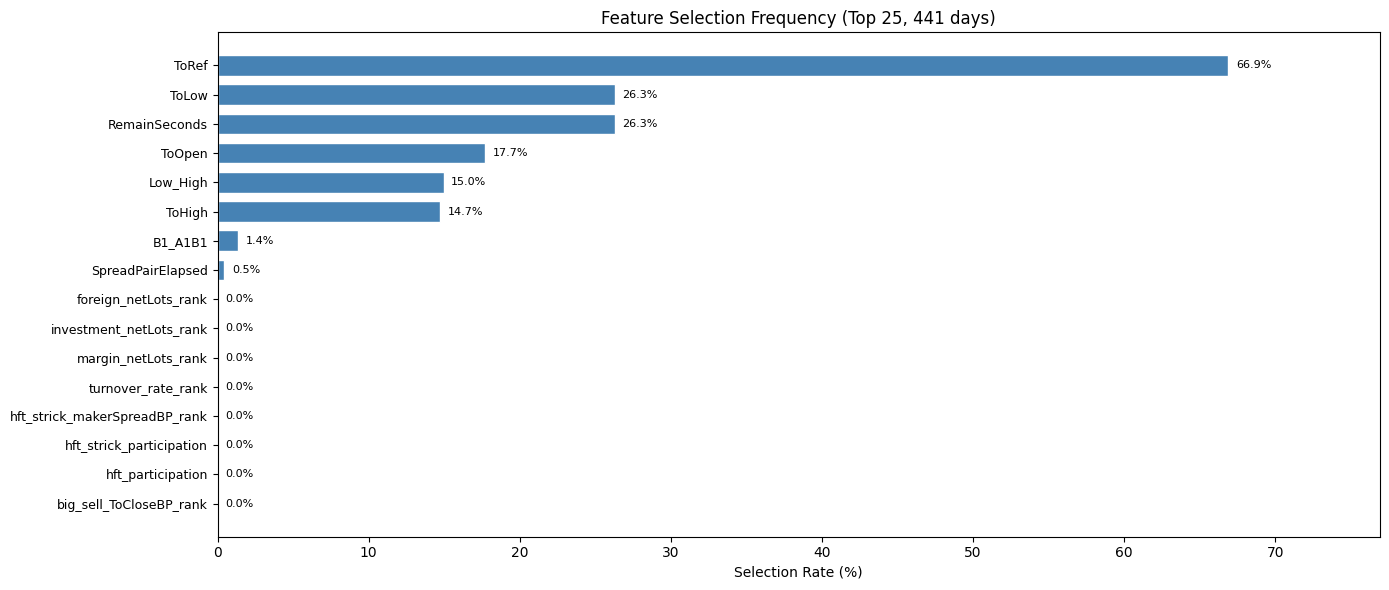


📊 [2/4] Feature Selection Heatmap


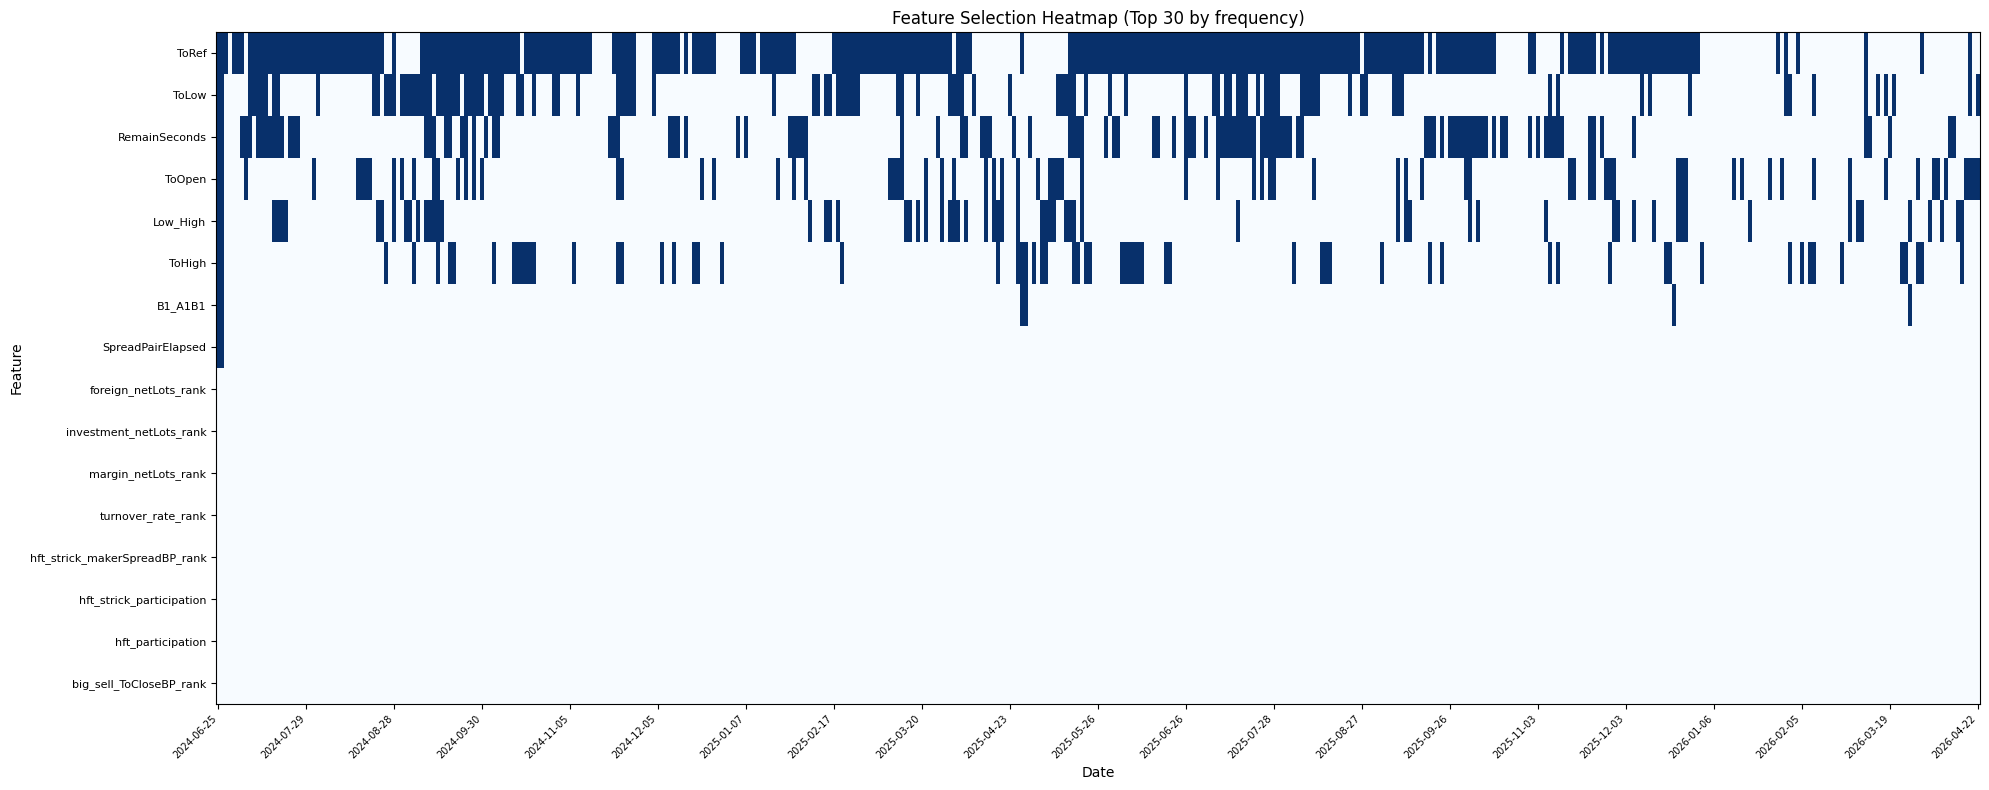


📊 [3/4] Standardized Coefficient Importance


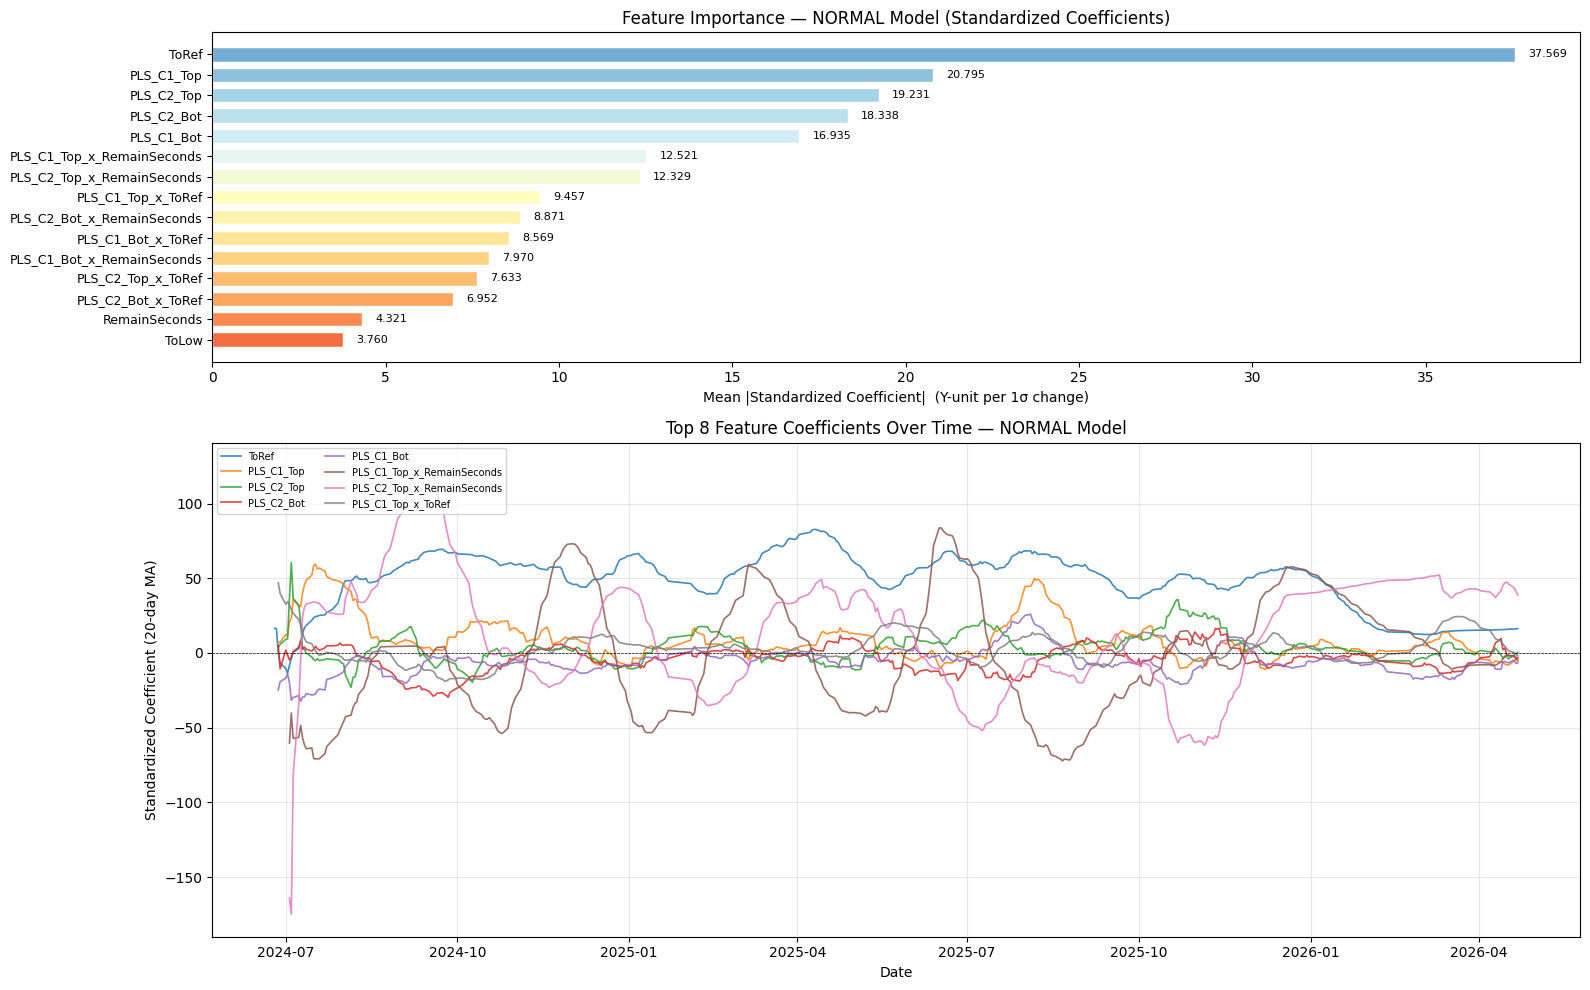


📊 [4/4] Coefficient Stability


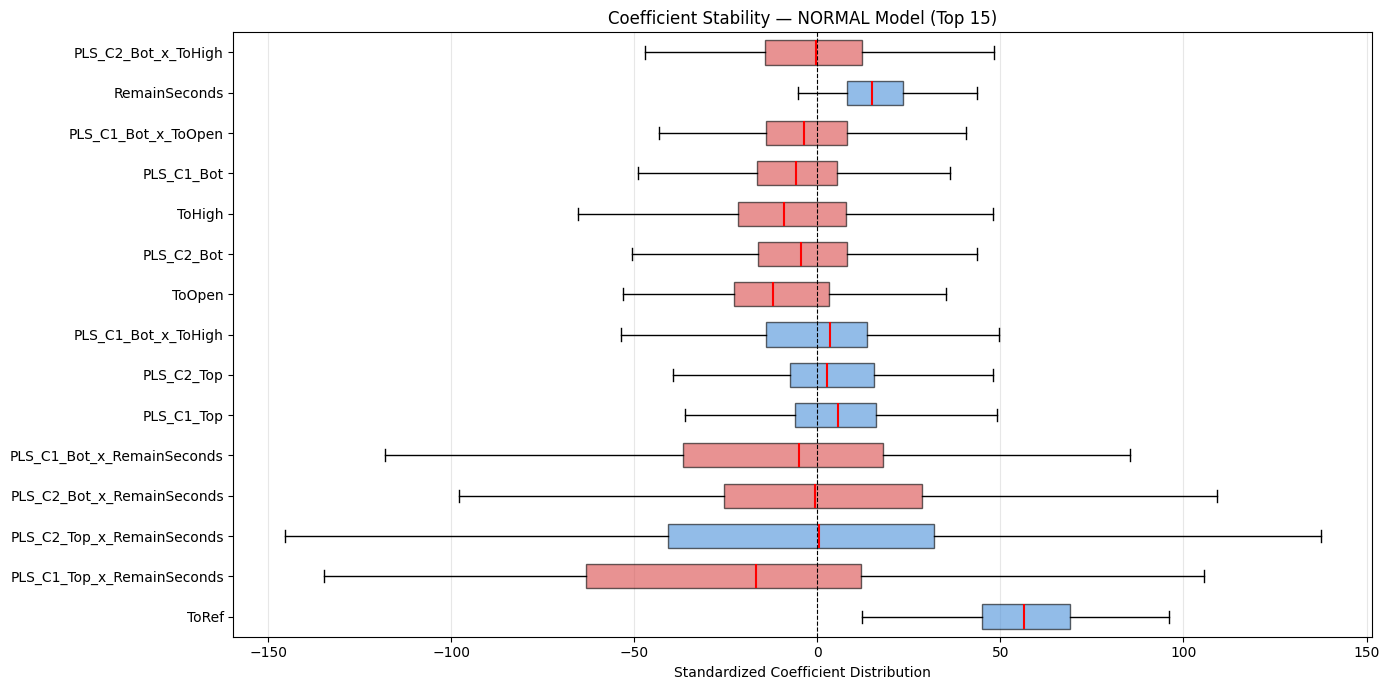

In [15]:

from src.research.negFill.model_analysis import plot_model_dashboard
# from model_analysis import plot_model_dashboard

plot_model_dashboard(result, model_type='normal')

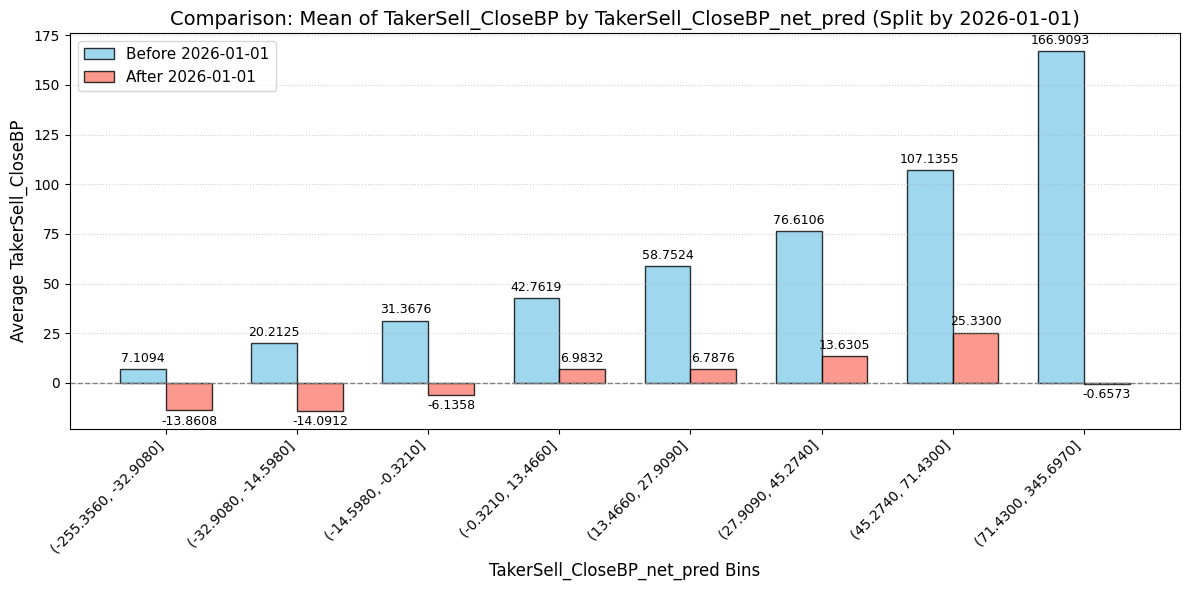

In [16]:
# QcutAnalyzer.plot_qcut_analysis(signal_df.assign( TakerSell_CloseBP_net_pred = signal_df.TakerSell_CloseBP_net_pred + signal_df['20day_marketBeta'])[signal_df.isAbnormalDate == 0], 'TakerSell_CloseBP_net_pred', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01',  q= 8)
QcutAnalyzer.plot_qcut_analysis(signal_df[signal_df.isAbnormalDate == 0], 'TakerSell_CloseBP_net_pred', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01',  q= 8)
# QcutAnalyzer.plot_qcut_analysis(signal_df[signal_df.isAbnormalDate == 0], 'TakerSell_CloseBP_net_pred', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01',  q= 8)


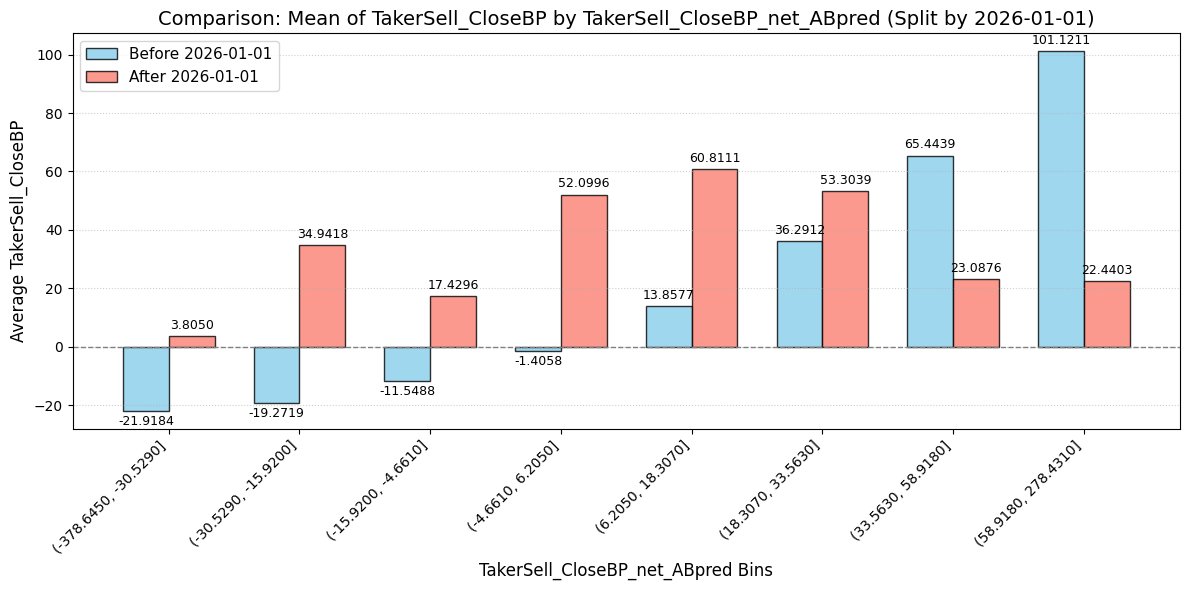

In [17]:
QcutAnalyzer.plot_qcut_analysis(signal_df[signal_df.isAbnormalDate == 1], 'TakerSell_CloseBP_net_ABpred', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01', q=8)


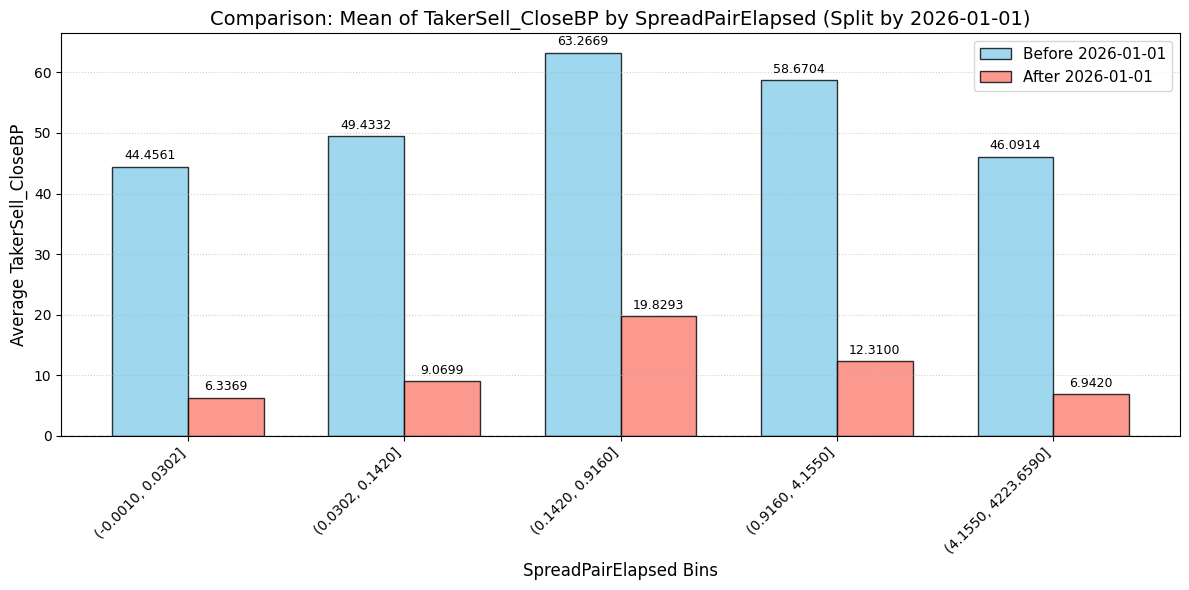

In [18]:
QcutAnalyzer.plot_qcut_analysis(signal_df, 'SpreadPairElapsed', 'TakerSell_CloseBP', date_col='Date', split_date='2026-01-01',q=10)


In [132]:
from numpy._core.defchararray import upper
condition = pd.Series( [True for i in range(len(signal_df))] )
# condition =   (signal_df.ToOpen <0)# (signal_df.Position<200) #(signal_df.big_sell_ToCloseBP > 20 ) & (signal_df.InOut < 0 ) & (signal_df.FillLots > signal_df.big_sell_lots)
# condition = condition | ((signal_df.Spread <= 1 ) & ((signal_df.SpreadPairSeq>5) & (signal_df.SpreadPairID > 5)))
# condition = condition & ((( signal_df.TakerSell_CloseBP_net_pred * (signal_df.isAbnormalDate == 0 ) >  40)  ) | (( signal_df.TakerSell_CloseBP_net_ABpred * (signal_df.isAbnormalDate == 1 ) >  60) )) #&(signal_df.SpreadCountAtSameCount <= 1)#& (signal_df.TakerSell_CloseBP_net_pred > 0) #& ((signal_df.netTotalFillLotsRank>1800)|(signal_df.netAmountRank>1800))
condition = condition & ((( signal_df.TakerSell_CloseBP_net_pred * (signal_df.isAbnormalDate == 0 ) >  30) & ( signal_df.TakerSell_CloseBP_netM_pred * (signal_df.isAbnormalDate == 0 ) >  -20) ) | (( signal_df.TakerSell_CloseBP_net_ABpred * (signal_df.isAbnormalDate == 1 ) >  30) & ( signal_df.TakerSell_CloseBP_netM_ABpred * (signal_df.isAbnormalDate == 1 ) >  -20))) #&(signal_df.SpreadCountAtSameCount <= 1)#& (signal_df.TakerSell_CloseBP_net_pred > 0) #& ((signal_df.netTotalFillLotsRank>1800)|(signal_df.netAmountRank>1800))
print( signal_df[condition].TakerSell_CloseBP.describe() )
print('')
print( 'cap BP : '+str( round(signal_df[condition].groupby(['Date','QuoteCode']).TakerSell_CloseBP.first().mean() ) ) )
print( 'averge prod num : '+str( round(signal_df[condition].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

condition_recent = condition & (signal_df.Date > pd.to_datetime('2026-01-01')) # & (signal_df.Date.dt.strftime('%Y%m%d').astype(int) > 20260101) #& (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )
print( signal_df[condition_recent].TakerSell_CloseBP.describe() ) 
print('')
print( 'cap BP : '+str( round(signal_df[condition_recent].groupby(['Date','QuoteCode']).TakerSell_CloseBP.first().mean() ) ) )
print( 'averge prod num : '+str( round(signal_df[condition_recent].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

count    2.457794e+06
mean     9.718382e+01
std      3.137785e+02
min     -9.995294e+02
25%     -4.987531e+01
50%      1.515152e+02
75%      2.946955e+02
max      1.388889e+03
Name: TakerSell_CloseBP, dtype: float64

cap BP : 72
averge prod num : 71.61
count    484468.000000
mean         15.311787
std         387.379527
min        -999.529412
25%        -305.343511
50%          30.211480
75%         280.112045
max        1316.872428
Name: TakerSell_CloseBP, dtype: float64

cap BP : 14
averge prod num : 70.14


In [156]:
# signal_df_model = signal_df[ condition  ].sort_values(['Date','QuoteCode', 'TransTime']).reset_index(drop=True) #(signal_df.SpreadPairElapsed > 0.1)  &
signal_df_model = signal_df[ condition & (signal_df.SpreadPairElapsed > 0.1)  & ((signal_df.AmountRank_canDayTrade<=100) |(signal_df.day_amount_rank <=100))  ].sort_values(['Date','QuoteCode', 'TransTime']).reset_index(drop=True) 

signal_df[ (signal_df.Date) ==signal_df.Date.max()][signal_df.QuoteCode=='3042']


signal_df[ (signal_df.Date == pd.to_datetime('2026-04-20') ) & (signal_df.QuoteCode == '2367') &(signal_df.ChannelSeq <= 507070)][[
    'TransTime','QuoteCode','ChannelSeq','BidPrice1','TakerSell_CloseBP_net_pred','TakerSell_CloseBP_net_ABpred','AmountRank_canDayTrade','day_amount_rank','hft_strick_makerSpreadBP','investment_netLots','ToLow',
   'ToHigh',   'Low_High',   'ToRef',   'ToOpen',   'B1_A1B1',   'RemainSeconds']].tail(1)
test_row = signal_df[ (signal_df.Date == pd.to_datetime('2026-04-20') ) & (signal_df.QuoteCode == '4931') &(signal_df.ChannelSeq <= 525339)][[
    'TransTime','QuoteCode','ChannelSeq','BidPrice1','TakerSell_CloseBP_net_pred','TakerSell_CloseBP_net_ABpred','AmountRank_canDayTrade','day_amount_rank','hft_strick_makerSpreadBP','investment_netLots',
    'ToLow',   'ToHigh',   'Low_High',   'ToRef',   'ToOpen',   'B1_A1B1',   'RemainSeconds']].tail(1)
test_row

coef_view =  np.array([ -327.8939514160156, -437.1385192871094, -0.9559449553489685,	2317.24560546875,	324.37530517578125, -20.37383270263672, 0.003649163991212845])
intercept = -26.025564193725586

row_view = np.array([ test_row[x].iloc[0] for x in ['ToLow',   'ToHigh',   'Low_High',   'ToRef',   'ToOpen',   'B1_A1B1',   'RemainSeconds'] ])
sum(coef_view * row_view) + intercept

In [164]:
signal_df_model['PosLots'] = signal_df_model.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumcount') + 1
signal_df_model['Position'] = signal_df_model.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumsum') / 10
signalwithRisk_df = signal_df_model[  
(signal_df_model.Position < 200)
#  (~((signal_df_model.PosLots >1) & (signal_df_model.Position > 50))) & (signal_df_model.BidPrice1<500)
# ( ((signal_df_model.Position < 500)&((signal_df_model.AmountRank < 50) | (signal_df_model.day_amount_rank<50))) |((signal_df_model.Position < 200)&((signal_df_model.AmountRank < 100) | (signal_df_model.day_amount_rank<100))) | ((signal_df_model.Position < 100)))
& (signal_df_model.BidPrice1<1000)  
& ( (signal_df_model.hft_strick_makerSpreadBP > -70) | (signal_df_model.hft_strick_makerSpreadBP.isna()))
# & ((signal_df_model.investment_netLots <= 0 )) 
# & (signal_df_model.OTC ==1)
#  & ((signal_df_model.ToRef>0))
      ].reset_index(drop=True)
# signalwithRisk_df = signal_df_model[ (signal_df_model.PosLots ==1) & (signal_df_model.BidPrice1 <= 100)].reset_index(drop=True)
signalwithRisk_df['Date'] = signalwithRisk_df.Date.dt.strftime('%Y%m%d')


In [165]:
signalwithRisk_df[ signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ][['TransTime','QuoteCode','ValueCode','RecordLow','RecordHigh','RecordHigh','ChannelSeq','BidPrice1','TakerSell_CloseBP_net_pred'] +feature_columns].groupby('QuoteCode').first().sort_values(by='TransTime').reset_index(drop=True)

,TransTime,ValueCode,RecordLow,RecordHigh,RecordHigh,ChannelSeq,BidPrice1,TakerSell_CloseBP_net_pred,ToLow,ToHigh,Low_High,ToRef,ToOpen,B1_A1B1,RemainSeconds,SpreadPairElapsed
0,2026-04-22 09:00:30.264457,3231,144.0,145.00,145.00,210326,144.50,46.095455,0.006920,0.000000,1.000000,0.000000,-0.003448,0.006944,15869,0.577845
1,2026-04-22 09:00:30.339047,5498,86.0,87.00,87.00,100933,86.80,142.325989,0.009627,0.002407,0.800000,0.044525,0.001153,0.666667,15869,0.171006
2,2026-04-22 09:00:30.820856,1303,88.1,88.80,88.80,211995,88.70,45.258648,0.005656,0.002262,0.714286,0.003394,-0.001126,0.025000,15869,0.481376
3,2026-04-22 09:00:31.242763,8150,76.5,77.40,77.40,213473,76.90,124.427017,0.008097,0.004049,0.666667,0.037787,0.003916,0.500000,15868,0.111900
4,2026-04-22 09:00:31.848649,1802,74.0,74.70,74.70,215281,74.60,61.346439,0.009434,0.000000,1.000000,0.005391,0.001342,0.011364,15868,0.237209
5,2026-04-22 09:00:32.689542,6182,43.5,44.05,44.05,104588,43.65,40.439335,0.002312,0.010405,0.181818,0.009249,-0.009081,0.250000,15867,0.112357
6,2026-04-22 09:00:34.061718,2382,341.0,344.00,344.00,222209,342.00,37.526638,0.002941,0.005882,0.333333,0.005882,0.000000,0.090909,15865,0.134027
7,2026-04-22 09:00:35.393393,3260,398.0,403.00,403.00,108225,401.50,85.453857,0.010165,0.002541,0.800000,0.020330,-0.003722,0.250000,15864,0.101994
8,2026-04-22 09:00:36.554906,8039,148.5,150.00,150.00,229974,149.00,65.219650,0.003413,0.006826,0.333333,0.017065,-0.006667,0.026316,15863,0.229958
9,2026-04-22 09:00:36.762959,6770,55.2,56.10,56.10,230632,55.30,66.904617,0.003704,0.012963,0.222222,0.024074,-0.012500,0.435065,15863,0.645370


for d in signalwithRisk_df[lambda x : x.Date.astype(int) >= 20260420].Date.unique() :
    signalwithRisk_df[lambda x : x.Date == d].reset_index(drop=True).to_csv(f'{d}_30w.csv')

In [166]:
signalwithRisk_df[ signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ].QuoteCode.unique()

<ArrowStringArray>
['1303', '1802', '2301', '2327', '2376', '2382', '3006', '3035', '3044',
 '3105', '3189', '3231', '3260', '3406', '3551', '3701', '3709', '4768',
 '4967', '4973', '5386', '5439', '5498', '6139', '6182', '6205', '6257',
 '6285', '6291', '6415', '6488', '6526', '6770', '8039', '8046', '8150']
Length: 36, dtype: str

In [167]:
signalwithRisk_df[ (signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max()) & (signalwithRisk_df.FutureHigh > signalwithRisk_df.RefPrice *1.08) ].QuoteCode.unique()

<ArrowStringArray>
['3044', '3701', '4967', '6291', '6526', '6770', '8039', '8150']
Length: 8, dtype: str

In [168]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()
position = (signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum()

rank_series = series1.rank(pct=True)

dateSeq = -1

# 取得最後一天的排名
latest_date = series1.index[dateSeq]
latest_rank = rank_series.iloc[dateSeq]

print(f"日期: {latest_date}")
print(f"單邊部位: {position.iloc[dateSeq]:.2f} 萬")
print(f"損益: {series1.iloc[dateSeq]:.2f} 萬")
print(f"損益: {series1.iloc[dateSeq]/position.iloc[dateSeq]*100 :.2f} % ")

rank_series = series1.rank()
latest_rank2 = rank_series.iloc[dateSeq]
print(f"排名: {latest_rank2},  {latest_rank :.2%}") # 例如 85.00%，代表贏過歷史 85% 的天數




日期: 20260422
單邊部位: 5022.72 萬
損益: -16.73 萬
損益: -0.33 % 
排名: 79.0,  18.00%


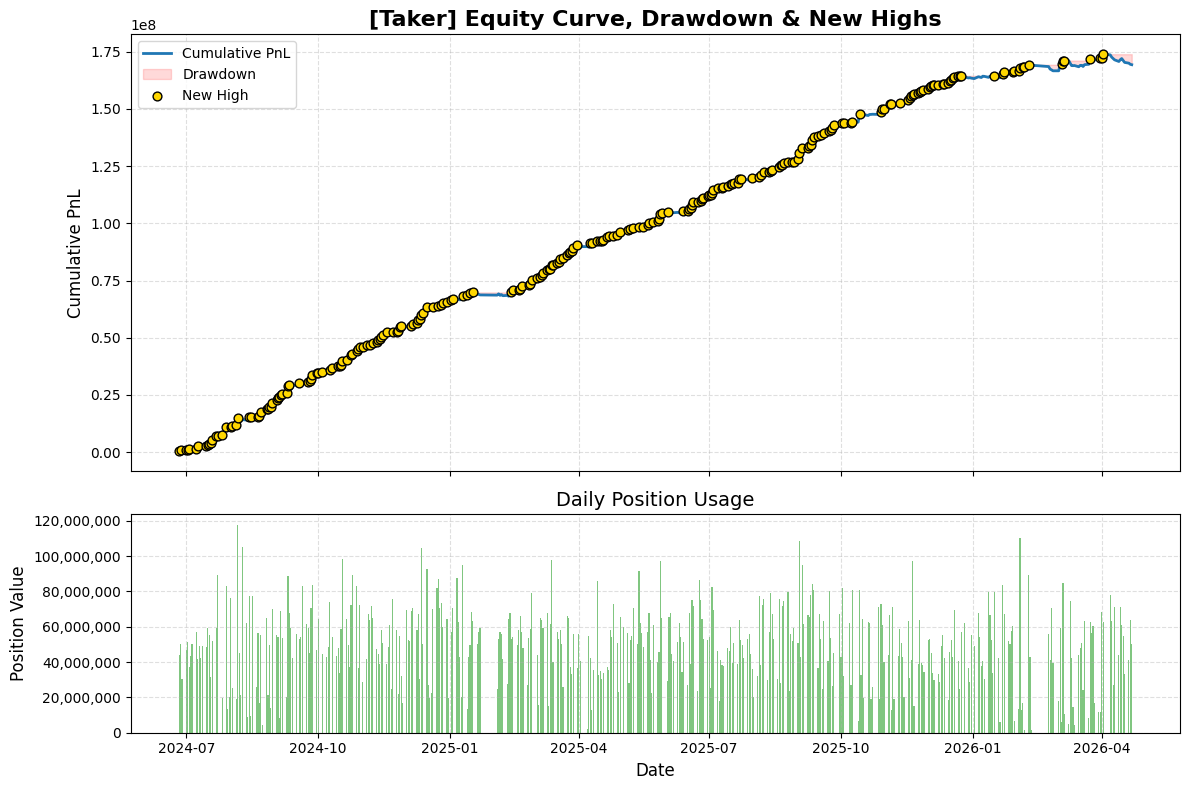


  回測模式: Taker
指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 16,931.08
近一年報酬（萬）      : 7,504.72
風報比                  : 36.86
年化 Sharpe          : 8.56
創高最長費時 (天)     : 14
平均每日交易商品數   : 38.49

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 183.08%
近一年報酬率（近一年平均部位）: 151.13%
勝率 (日/單筆)      : 69.25% / 69.48%
平均BP (單筆/單位) : 85.32 / 76.2823

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -158.96 萬
MDD金額/佔平均比   : -459.29 萬 / 9.08%
平均/最大部位(萬)  : 5,055.87 / 11,780.56
平均最大單一商品比  : 6.01%



In [169]:
bt = BackTest(signalwithRisk_df)
results = bt.run_analysis()

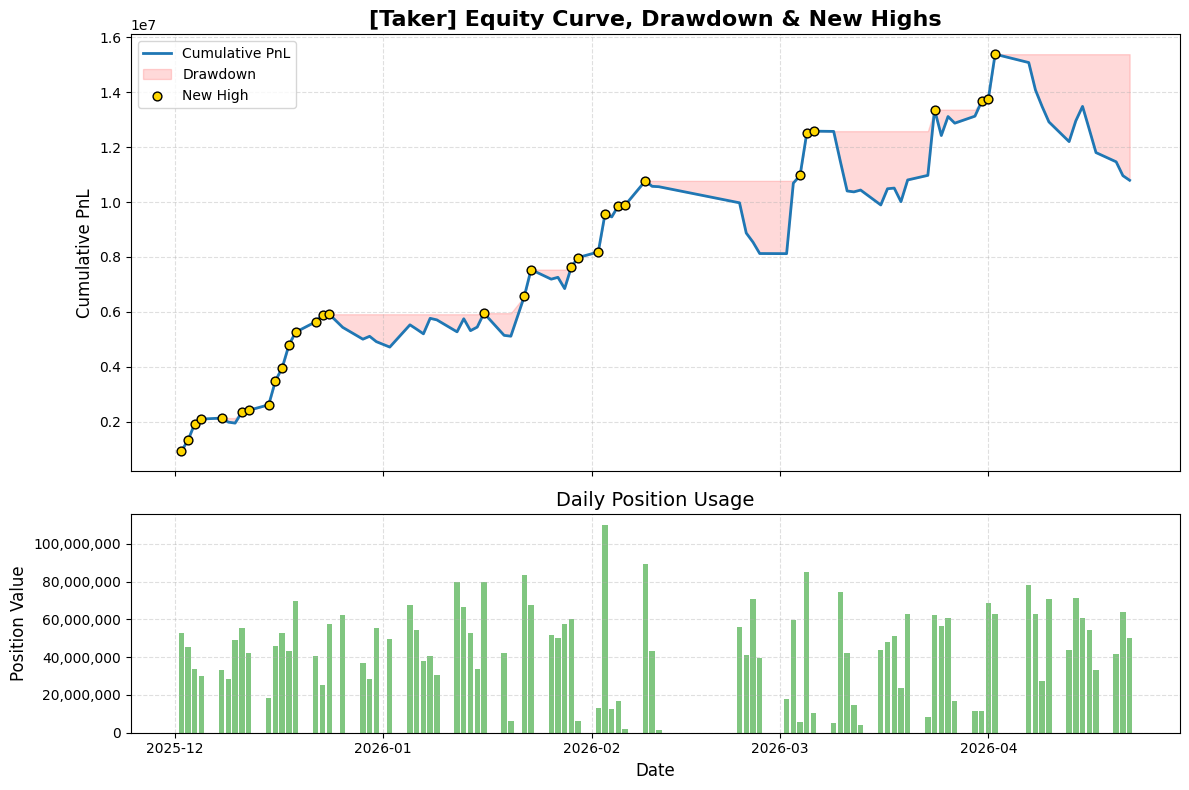


  回測模式: Taker
指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 1,079.15
近一年報酬（萬）      : 1,079.15
風報比                  : 2.35
年化 Sharpe          : 2.77
創高最長費時 (天)     : 14
平均每日交易商品數   : 33.70

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 64.92%
近一年報酬率（近一年平均部位）: 24.08%
勝率 (日/單筆)      : 53.93% / 60.97%
平均BP (單筆/單位) : 51.95 / 27.0518

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -110.21 萬
MDD金額/佔平均比   : -459.29 萬 / 10.25%
平均/最大部位(萬)  : 4,482.25 / 11,010.96
平均最大單一商品比  : 9.35%



In [170]:
bt = BackTest(signalwithRisk_df[signalwithRisk_df.Date.astype(int) > 20251201])
results = bt.run_analysis()


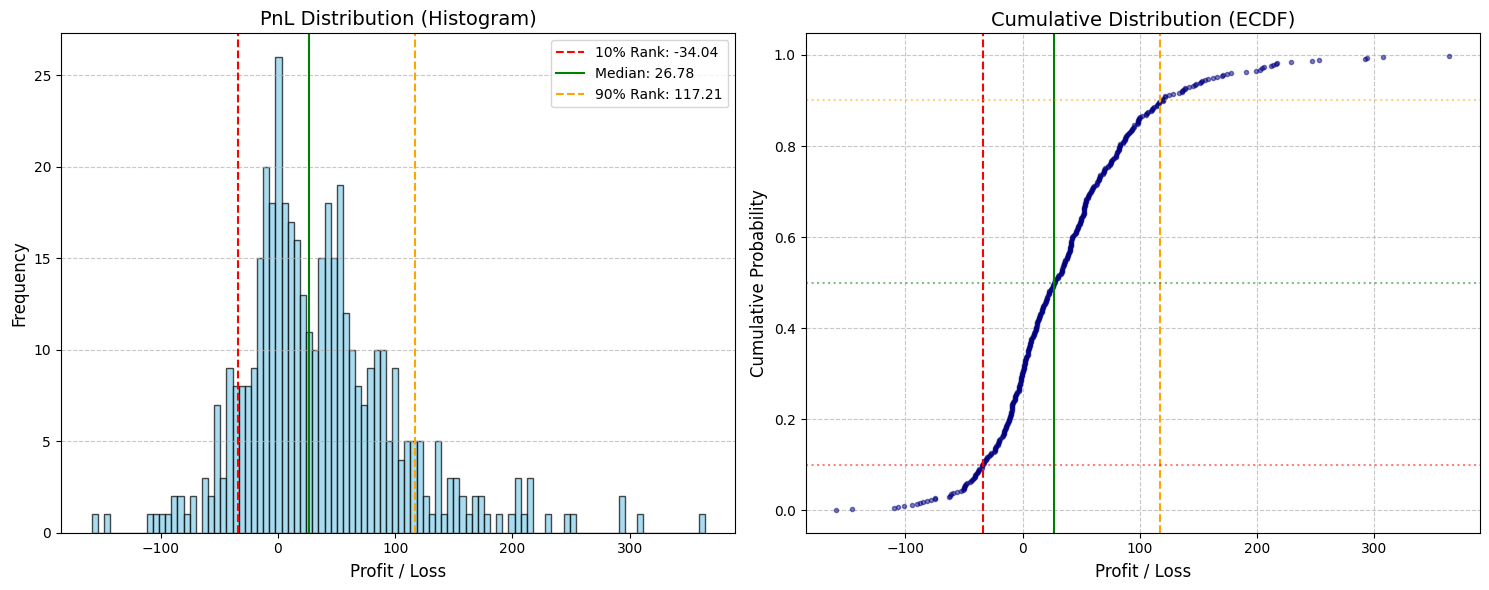

In [28]:

# 1. 計算分位數數值
q10 = series1.quantile(0.1)
q50 = series1.quantile(0.5)
q90 = series1.quantile(0.9)

# 2. 排序數據以計算累積機率 (ECDF)
sorted_data = np.sort(series1)
y_values = np.arange(len(sorted_data)) / float(len(sorted_data))

# 建立畫布
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 圖左：直方圖 (棒狀圖) ---
axes[0].hist(series1, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
# 加入垂直分界線
axes[0].axvline(q10, color='red', linestyle='--', linewidth=1.5, label=f'10% Rank: {q10:.2f}')
axes[0].axvline(q50, color='green', linestyle='-', linewidth=1.5, label=f'Median: {q50:.2f}')
axes[0].axvline(q90, color='orange', linestyle='--', linewidth=1.5, label=f'90% Rank: {q90:.2f}')

axes[0].set_title('PnL Distribution (Histogram)', fontsize=14)
axes[0].set_xlabel('Profit / Loss', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend() # 顯示圖例
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- 圖右：累積圖 (ECDF) ---
axes[1].plot(sorted_data, y_values, marker='.', linestyle='none', color='navy', alpha=0.5)
# 加入垂直分界線 (X軸：損益數值)
axes[1].axvline(q10, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(q50, color='green', linestyle='-', linewidth=1.5)
axes[1].axvline(q90, color='orange', linestyle='--', linewidth=1.5)
# 加入水平參考線 (Y軸：排名百分比)
axes[1].axhline(0.1, color='red', linestyle=':', alpha=0.5)
axes[1].axhline(0.5, color='green', linestyle=':', alpha=0.5)
axes[1].axhline(0.9, color='orange', linestyle=':', alpha=0.5)

axes[1].set_title('Cumulative Distribution (ECDF)', fontsize=14)
axes[1].set_xlabel('Profit / Loss', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [29]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()


In [30]:
date_portfolio = series1.reset_index().rename(columns={0: 'PL'})
date_portfolio['Position'] = ( signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum().reset_index(drop=True)
date_portfolio['Return'] = date_portfolio['PL'] / date_portfolio['Position'] * 100

【分析 A】2025 以後 兩者報酬與風險特性：
- 獲利率 Pearson 相關性: -0.4899
- 0030_portfolio  : 日波動 2.0188 | 年化波動度 32.0481
- date_portfolio  : 日波動 1.2497 | 年化波動度 19.8389

【分析 B】2025 以後 各自賠最多的 20% 交易日重疊狀況：
- 在 0030_portfolio 最差的 61 天中，有 4.92% 的機率 date_portfolio 也處於極端虧損
- 在 date_portfolio 最差的 63 天中，有 4.76% 的機率 0030 也處於極端虧損



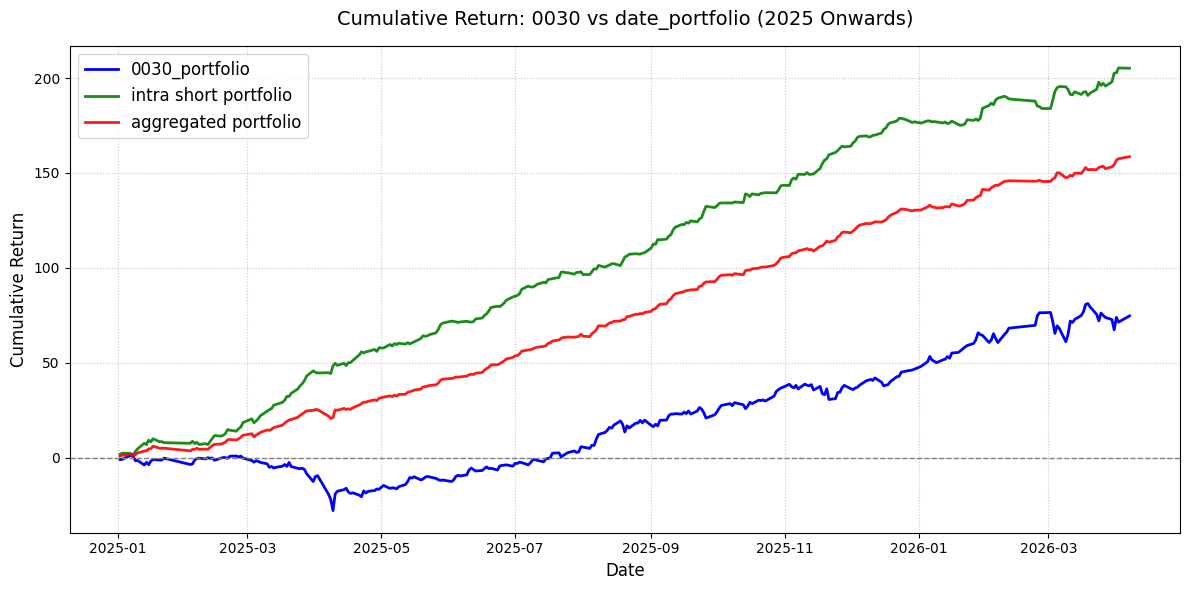

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. 讀取並處理 0030_portfolio.csv
# -------------------------------------------------------------------------
df_0030 = pd.read_csv('/home/kevin/Project/HFT/src/research/negFill/0030_portfolio.csv', encoding='utf-8-sig')

# 將 0030 的日期轉為 datetime 格式，方便後續篩選
df_0030['日期'] = pd.to_datetime(df_0030['日期'].astype(str), format='%Y%m%d')

# 👉 更正 1：篩選 2025 以後（包含 2025-01-01）
df_0030_filtered = df_0030[df_0030['日期'] >= '2025-01-01'].copy()
df_0030_filtered['獲利率'] = df_0030_filtered['獲利率'] * 100


# -------------------------------------------------------------------------
# 2. 處理 date_portfolio，對齊年份與格式
# -------------------------------------------------------------------------
# 👉 請確認這兩個變數對應您 date_portfolio 的實際欄位名稱：
date_col = 'Date'        # 日期欄位名稱
return_col = 'Return'    # 獲利率欄位名稱

dp_filtered = date_portfolio.copy()

# 若 date_portfolio 的日期在 index 上，請解除下面這行註解：
# dp_filtered = dp_filtered.reset_index() 

# 將該欄位轉為 datetime 格式，並篩選 2025 以後的資料
dp_filtered[date_col] = pd.to_datetime(dp_filtered[date_col].astype(str)) 
dp_filtered = dp_filtered[dp_filtered[date_col] >= '2025-01-01'].copy()


# -------------------------------------------------------------------------
# 合併兩者（取每日均有交易的交集日），並確保日期順序
# -------------------------------------------------------------------------
merged_df = pd.merge(
    df_0030_filtered[['日期', '獲利率']], 
    dp_filtered[[date_col, return_col]], 
    left_on='日期', 
    right_on=date_col, 
    how='inner'
)
merged_df = merged_df.sort_values('日期').reset_index(drop=True)


# =========================================================
# 分析 A：獲利率相關性與波動度
# =========================================================
correlation = merged_df['獲利率'].corr(merged_df[return_col])

# 👉 新增 2：計算波動度 (日標準差及乘上根號 252 的年化標準差)
vol_0030_daily = merged_df['獲利率'].std()
vol_0030_annual = vol_0030_daily * np.sqrt(252)

vol_dp_daily = merged_df[return_col].std()
vol_dp_annual = vol_dp_daily * np.sqrt(252)

print("【分析 A】2025 以後 兩者報酬與風險特性：")
print(f"- 獲利率 Pearson 相關性: {correlation:.4f}")
print(f"- 0030_portfolio  : 日波動 {vol_0030_daily:.4f} | 年化波動度 {vol_0030_annual:.4f}")
print(f"- date_portfolio  : 日波動 {vol_dp_daily:.4f} | 年化波動度 {vol_dp_annual:.4f}\n")


# =========================================================
# 分析 B：各自賠最多的 20% 交易日的重疊率 (基於原始 2025 以後的區間)
# =========================================================
thresh_0030 = df_0030_filtered['獲利率'].quantile(0.2)
thresh_dp = dp_filtered[return_col].quantile(0.2)

worst_days_0030 = set(df_0030_filtered[df_0030_filtered['獲利率'] <= thresh_0030]['日期'])
worst_days_dp = set(dp_filtered[dp_filtered[return_col] <= thresh_dp][date_col])

overlap_days = worst_days_0030.intersection(worst_days_dp)
union_days = worst_days_0030.union(worst_days_dp)

rate_0030 = len(overlap_days) / len(worst_days_0030) if len(worst_days_0030) > 0 else 0
rate_dp = len(overlap_days) / len(worst_days_dp) if len(worst_days_dp) > 0 else 0

print("【分析 B】2025 以後 各自賠最多的 20% 交易日重疊狀況：")
print(f"- 在 0030_portfolio 最差的 {len(worst_days_0030)} 天中，有 {rate_0030:.2%} 的機率 date_portfolio 也處於極端虧損")
print(f"- 在 date_portfolio 最差的 {len(worst_days_dp)} 天中，有 {rate_dp:.2%} 的機率 0030 也處於極端虧損\n")


# =========================================================
# 分析 C：繪製 2025 以後累計獲利率 (CumSum) 比較圖
# =========================================================
# 👉 新增 3：計算 CumSum 並畫在同一張圖
merged_df['0030_cumsum'] = merged_df['獲利率'].cumsum()
merged_df['dp_cumsum'] = merged_df[return_col].cumsum()

plt.figure(figsize=(12, 6))

# 把累進獲利畫出來
plt.plot(merged_df['日期'], merged_df['0030_cumsum'], label='0030_portfolio', color='blue', linewidth=2)
plt.plot(merged_df['日期'], merged_df['dp_cumsum'], label='intra short portfolio', color='green', linewidth=2, alpha=0.9)
plt.plot(merged_df['日期'],  (merged_df['0030_cumsum'] + merged_df['dp_cumsum']*1.8) / 2.8, label='aggregated portfolio', color='red', linewidth=2, alpha=0.9)

# 圖表美化
plt.title('Cumulative Return: 0030 vs date_portfolio (2025 Onwards)', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', linewidth=1) # 補上 0 軸線方便看有沒有賺錢
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

# 調整佈局並顯示
plt.tight_layout()
plt.show()



In [32]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import polars as pl
from tqdm import tqdm

PROJECT_ROOT = Path(os.path.abspath('')).parents[2]

import glob
# ======================================================================
# 1. 預先計算台積電 (2330) 的歷史季線 (60MA)
# (加入防呆機制，跳過欄位毀損的日期檔案，避免 SchemaError 崩潰)
# ======================================================================
print("預先計算台積電 60MA 中...")
files = glob.glob(f'{PROJECT_ROOT}/data/marketData/*_marketData.parquet')
dfs = []
for f in tqdm(files, desc="讀取台積電歷史"):
    try:
        # 只讀取需要的欄位並且立刻過濾 2330，節省大量記憶體！
        df_day = pl.read_parquet(f, columns=['date', 'quote_code', 'close_price'])
        tsmc_day = df_day.filter(pl.col('quote_code') == '2330')
        dfs.append(tsmc_day)
    except Exception as e:
        # 遇到破掉或缺少欄位的假期檔案直接略過
        pass
# 將所有天數合併並照日期排序
tsmc_hist = pl.concat(dfs, how="diagonal_relaxed").sort('date').to_pandas()
# 計算 60 天移動平均線 (季線)
tsmc_hist['MA60'] = tsmc_hist['close_price'].rolling(window=60).mean()
# 轉成字串字典
tsmc_hist['date_str'] = pd.to_datetime(tsmc_hist['date']).dt.strftime('%Y%m%d')
tsmc_ma60_dict = dict(zip(tsmc_hist['date_str'], tsmc_hist['MA60']))
# ======================================================================

# ======================================================================
# 2. 開始執行你的主要迴圈
# ======================================================================
dateData = []
for d in tqdm( date_portfolio.Date[:-1] ): 
    # 轉為字串以防找不到，請依據你 df 中 date 的實際樣子調整
    d_str = str(d).replace("-", "") 
    
    # 讀取 marketData
    maket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/marketData/{d_str}_marketData.parquet')
    premarket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/preMarket/{d_str}_preMarketData.parquet')
    
    maket_df['quote_code'] = maket_df['quote_code'].astype(str)
    premarket_df['QuoteCode'] = premarket_df['QuoteCode'].astype(str)
    
    merged_df = pd.merge(
        maket_df, 
        premarket_df, 
        left_on='quote_code', 
        right_on='QuoteCode', 
        how='inner'
    )
    
    merged_df['toOpen'] = (merged_df['open_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']
    merged_df['Return'] = (merged_df['close_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']

    # 取出 2330
    tsmc = merged_df[merged_df['quote_code'] == '2330']
    tsmcOpen = tsmc.toOpen.iloc[0]
    tsmcReturn = tsmc.Return.iloc[0]
    tsmcClose = tsmc.close_price.iloc[0]
    
    # ======== 新增：計算距離季線(60MA)的乖離幅度 ========
    # 從剛剛預先做好的字典取出當天的 60MA
    ma60_today = tsmc_ma60_dict.get(d_str)
    
    if pd.notna(ma60_today) and ma60_today > 0:
        # 乖離率 = (收盤價 - 季線) / 季線
        tsmc_dist_60MA = (tsmcClose - ma60_today) / ma60_today
    else:
        # 前 60 天資料不足時先填空
        tsmc_dist_60MA = np.nan 
    # ===================================================

    # day_amount_rank < 100 的 mean
    top_df = merged_df[ (merged_df['day_amount_rank'] <= 100) & (merged_df.allow_day_trade_mark_x == 'X')]
    topOpen = top_df.toOpen.mean(numeric_only=True)
    topCount = top_df.toOpen.count()
    topDrop = top_df.toOpen.apply(np.sign).mean(numeric_only=True)
    topReturn = top_df.Return.mean(numeric_only=True)
    
    # 將算出的距離季線報酬率 (tsmc_dist_60MA) 塞進 dateData 中
    dateData.append([tsmcOpen, tsmcReturn, tsmc_dist_60MA, topOpen, topDrop, topReturn, topCount])



預先計算台積電 60MA 中...


100%|██████████| 438/438 [00:16<00:00, 26.83it/s]


In [33]:
date_portfolio = series1.reset_index().rename(columns={0: 'PL'})
date_portfolio['Position'] = ( signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum().reset_index(drop=True)
date_portfolio['Return'] = date_portfolio['PL'] / date_portfolio['Position'] * 100

In [34]:
date_portfolio = pd.concat( [date_portfolio, pd.DataFrame(columns=['tsmOpen', 'tsmReturn', 'tsmc_dist_60MA', 'topOpen', 'topDrop', 'topReturn','topCount'], data = dateData) ], axis = 1)

In [35]:
date_portfolio= date_portfolio.reset_index(drop=True)

In [36]:
date_portfolio['topStd_10D'] = (date_portfolio.topDrop).rolling(10,min_periods=1).std().shift()
date_portfolio['topReturnlast_10D'] = (date_portfolio.topReturn).rolling(10,min_periods=1).std().shift()

In [37]:
date_portfolio['Count'] =  (date_portfolio.topOpen < 0.0025) #| (date_portfolio.topReturnlast_10D > 0.015) 
# date_portfolio['Count'] =  (date_portfolio.topOpen < 0.00) | (date_portfolio.topReturnlast_10D < -0.025) 

In [38]:
date_portfolio[['Date', 'topOpen']].to_csv('open.csv')

In [39]:
date_portfolio['Count'].mean()

np.float64(0.36446469248291574)

<Axes: >

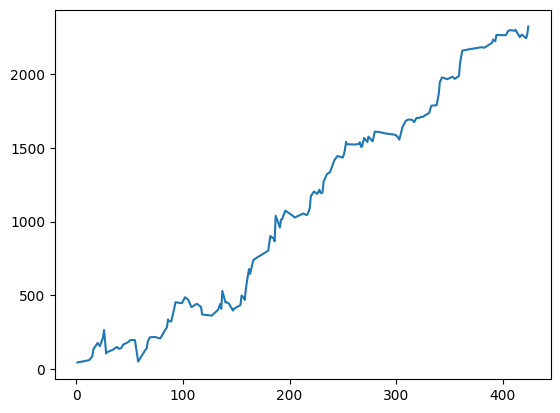

In [40]:
date_portfolio[ (date_portfolio.Count == 1) ].PL.cumsum().plot()
# date_portfolio[ (date_portfolio.topReturnlast_10D.rolling(window=100,min_periods=1).rank(ascending=True, pct=True) )<0.05 ].PL.cumsum().plot()

<Axes: >

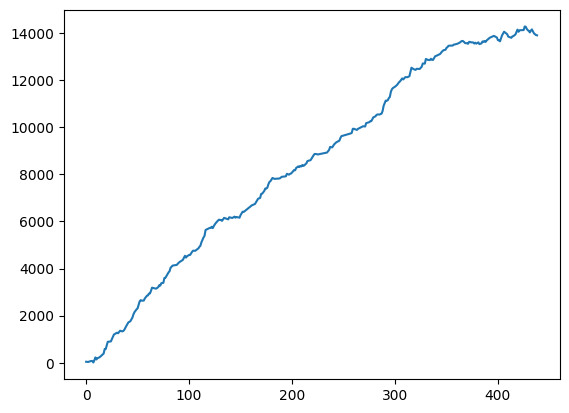

In [41]:
date_portfolio[ date_portfolio.Count == 0 ].PL.cumsum().plot()

In [42]:
abonraml_DATE = date_portfolio[ (date_portfolio.Count ==1) ].Date.to_list()

In [43]:
abonraml_DATE

['20240627',
 '20240702',
 '20240712',
 '20240717',
 '20240718',
 '20240726',
 '20240730',
 '20240731',
 '20240802',
 '20240805',
 '20240807',
 '20240808',
 '20240813',
 '20240815',
 '20240821',
 '20240823',
 '20240827',
 '20240829',
 '20240904',
 '20240909',
 '20240913',
 '20240919',
 '20240930',
 '20241001',
 '20241004',
 '20241008',
 '20241016',
 '20241022',
 '20241023',
 '20241029',
 '20241101',
 '20241104',
 '20241105',
 '20241107',
 '20241112',
 '20241113',
 '20241121',
 '20241126',
 '20241129',
 '20241204',
 '20241211',
 '20241217',
 '20241218',
 '20241219',
 '20241231',
 '20250109',
 '20250113',
 '20250114',
 '20250115',
 '20250120',
 '20250121',
 '20250203',
 '20250207',
 '20250210',
 '20250218',
 '20250219',
 '20250221',
 '20250224',
 '20250225',
 '20250226',
 '20250303',
 '20250304',
 '20250307',
 '20250311',
 '20250327',
 '20250331',
 '20250402',
 '20250407',
 '20250408',
 '20250409',
 '20250411',
 '20250415',
 '20250416',
 '20250417',
 '20250422',
 '20250429',
 '20250506',

import json

# 假設這是你的異常日期清單 (字串格式)

# 將 list 存成 JSON 檔案
with open('abnormal_dates.json', 'w') as f:
    json.dump(abonraml_DATE, f)
    
print("異常日期清單已儲存！")

In [44]:
condition = date_portfolio.test > -0.005
print(condition.sum())
date_portfolio[ condition ].PL.cumsum().plot()

AttributeError: 'DataFrame' object has no attribute 'test'